# Monthly means of z, temp, sal

Maps of the **mean particle property** (depth, temperature, salinity) per spatial bin, grouped by release month.
Same weighted-`xhist` approach as the particle density: weight the histogram by the variable, divide by the count → mean value per bin.

In [ ]:
import xarray as xr
from pathlib import Path
from xhistogram.xarray import histogram as xhist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cmocean as cm

In [2]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=3, memory_limit=15e9)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 12,Total memory: 55.88 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38523,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43473,Total threads: 3
Dashboard: http://127.0.0.1:42135/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:40533,


In [ ]:
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

In [3]:
stores1 = sorted(Path("/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678").glob("Parcels_run_*_*.zarr"))
stores2 = sorted(Path("/work/bk1450/b383184/Amazon/Mercator/data/tracks_67891").glob("Parcels_run_*_*.zarr"))
stores3 = sorted(Path("/work/bk1450/b383184/Amazon/Mercator/data/tracks_78876").glob("Parcels_run_*_*.zarr"))

stores = stores1 + stores2 + stores3
len(stores)

1628

In [4]:
ds_list = [xr.open_zarr(s) for s in stores]
ds = xr.concat(ds_list, dim="trajectory")
# NOTE: we KEEP z, temp, sal this time (do not drop them)
ds

<xarray.Dataset> Size: 602GB
Dimensions:     (trajectory: 16280000, obs: 925)
Coordinates:
  * obs         (obs) int32 4kB 0 1 2 3 4 5 6 7 ... 918 919 920 921 922 923 924
  * trajectory  (trajectory) int64 130MB 0 1 2 3 4 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float64 120GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon         (trajectory, obs) float64 120GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    sal         (trajectory, obs) float32 60GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    temp        (trajectory, obs) float32 60GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 120GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    z           (trajectory, obs) float64 120GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [5]:
# trim trailing obs steps where no particle has data
num_valid_obs_steps = int(ds.lat.notnull().any("trajectory").sum().compute().data[()])
ds = ds.isel(obs=slice(None, num_valid_obs_steps))
ds

<xarray.Dataset> Size: 483GB
Dimensions:     (trajectory: 16280000, obs: 741)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory  (trajectory) int64 130MB 0 1 2 3 4 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float64 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon         (trajectory, obs) float64 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    sal         (trajectory, obs) float32 48GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    temp        (trajectory, obs) float32 48GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    z           (trajectory, obs) float64 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [6]:
# release time + month, exactly as in the density notebook
ds = ds.assign(start_time=ds.time.isel(obs=0).compute())
ds = ds.assign(start_month=ds.start_time.dt.month)

In [7]:
lat_min = ds.lat.min().compute().data[()]
lat_max = ds.lat.max().compute().data[()]
lon_min = ds.lon.min().compute().data[()]
lon_max = ds.lon.max().compute().data[()]

lat_bins = np.linspace(lat_min, lat_max, 30)
lon_bins = np.linspace(lon_min, lon_max, 80)

## Weighted histogram → monthly mean per variable

In [8]:
def calc_one(d, v):
    """Binned sum and count for a SINGLE variable, weighted by that variable.
    Positions where the variable is NaN are excluded by masking the coordinates."""
    w = d[v]
    lon = d.lon.where(w.notnull())   # drop samples with no value for this var
    lat = d.lat.where(w.notnull())
    count = xhist(lon, lat, bins=[lon_bins, lat_bins],
                  dim=["trajectory"], bin_dim_suffix="")
    wsum  = xhist(lon, lat, bins=[lon_bins, lat_bins],
                  dim=["trajectory"], weights=w, bin_dim_suffix="")
    return xr.Dataset({"sum": wsum, "count": count})

# group by release month, one variable at a time
monthly_z    = ds.groupby("start_month").apply(lambda d: calc_one(d, "z"))
monthly_temp = ds.groupby("start_month").apply(lambda d: calc_one(d, "temp"))
monthly_sal  = ds.groupby("start_month").apply(lambda d: calc_one(d, "sal"))

In [9]:
def monthly_mean(m, name):
    """collapse the obs axis (skip the initial release position), then mean = sum / count"""
    m = m.isel(obs=slice(1, None)).sum("obs")
    mean = m["sum"] / m["count"].where(m["count"] > 0)
    return mean.rename(name).compute()

mean_z    = monthly_mean(monthly_z,    "z")
mean_temp = monthly_mean(monthly_temp, "temp")
mean_sal  = monthly_mean(monthly_sal,  "sal")

# store each one separately (zarr)
mean_z.to_dataset().to_zarr("mean_z_month",       mode="w")
mean_temp.to_dataset().to_zarr("mean_temp_month", mode="w")
mean_sal.to_dataset().to_zarr("mean_sal_month",   mode="w")

# (to save as netCDF instead, swap the three lines above for:)
# mean_z.to_netcdf("mean_z_month.nc")
# mean_temp.to_netcdf("mean_temp_month.nc")
# mean_sal.to_netcdf("mean_sal_month.nc")

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 21.74 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 21.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Send

## Plots — one 3×4 monthly grid per variable

In [8]:
mean_z = xr.open_dataset('mean_z_month.zarr').compute()
mean_sal = xr.open_dataset('mean_sal_month.zarr').compute()
mean_temp = xr.open_dataset('mean_temp_month.zarr').compute() 

In [138]:
from matplotlib.colors import BoundaryNorm

sali = np.arange(30,36,0.5)
cmaps = {"z": 'turbo', "temp": cm.cm.balance, "sal": "jet"}
labels = {"z": "mean depth [m]", "temp": "mean temperature [°C]", "sal": "mean salinity"}
labs = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']

def plot_monthly(da, cmap, label, name):
    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(
        4, 3,
        figsize=(12, 8),
        subplot_kw=dict(projection=proj)
    )
    ax = ax.ravel()
    vmin = float(da.min()); vmax = float(da.max())

    # --- depth-specific discrete levels ---
    if name == "z":
        levels = [0, 50, 100, 150, 200, 300, 400, 500]
        norm = BoundaryNorm(levels, ncolors=plt.get_cmap(cmap).N, clip=True)
        
    if name == 'temp':
        levels = [0, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
        norm = BoundaryNorm(levels, ncolors=plt.get_cmap(cmap).N, clip=True)

    if name == 'sal':
        levels = np.insert(sali, 0, 0)
        norm = BoundaryNorm(levels, ncolors=plt.get_cmap(cmap).N, clip=True)

    for i in range(12):
        dd = da.sel(start_month=i + 1)

        plot_kw = dict(
            x="lon", y="lat", ax=ax[i], transform=proj,
            cmap=cmap, levels=levels, add_colorbar=False,
        )
        if norm is not None:
            plot_kw["norm"] = norm
        else:
            plot_kw.update(vmin=vmin, vmax=vmax)

        pcm = dd.plot.contourf(**plot_kw)

        ax[i].coastlines()
        ax[i].add_feature(cf.LAND, facecolor="#8e9497ff", zorder=0)
        ax[i].set_title(labs[i], fontsize=10)
        ax[i].set_xticks(
            np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max()) + 1e-6, 10),
            crs=proj
        )
        ax[i].set_yticks(
            np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max()) + 1e-6, 5),
            crs=proj
        )
        ax[i].xaxis.set_major_formatter(
            LongitudeFormatter(number_format=".0f", degree_symbol="°")
        )
        ax[i].yaxis.set_major_formatter(
            LatitudeFormatter(number_format=".0f", degree_symbol="°")
        )
        ax[i].tick_params(labelsize=8)
        ax[i].set_xlabel("")
        ax[i].set_ylabel("")

    fig.subplots_adjust(
        left=0.05, right=0.95,
        bottom=0.08, top=0.90,
        wspace=0.05, hspace=0.4
    )
    cbar = fig.colorbar(
        pcm, ax=ax, orientation="horizontal",
        fraction=0.05, pad=0.10
    )
    cbar.ax.set_xlabel(label, fontsize=10)
    plt.savefig(f"figures/mean_{name}_LPT.png", dpi=300, bbox_inches="tight")
    plt.show()

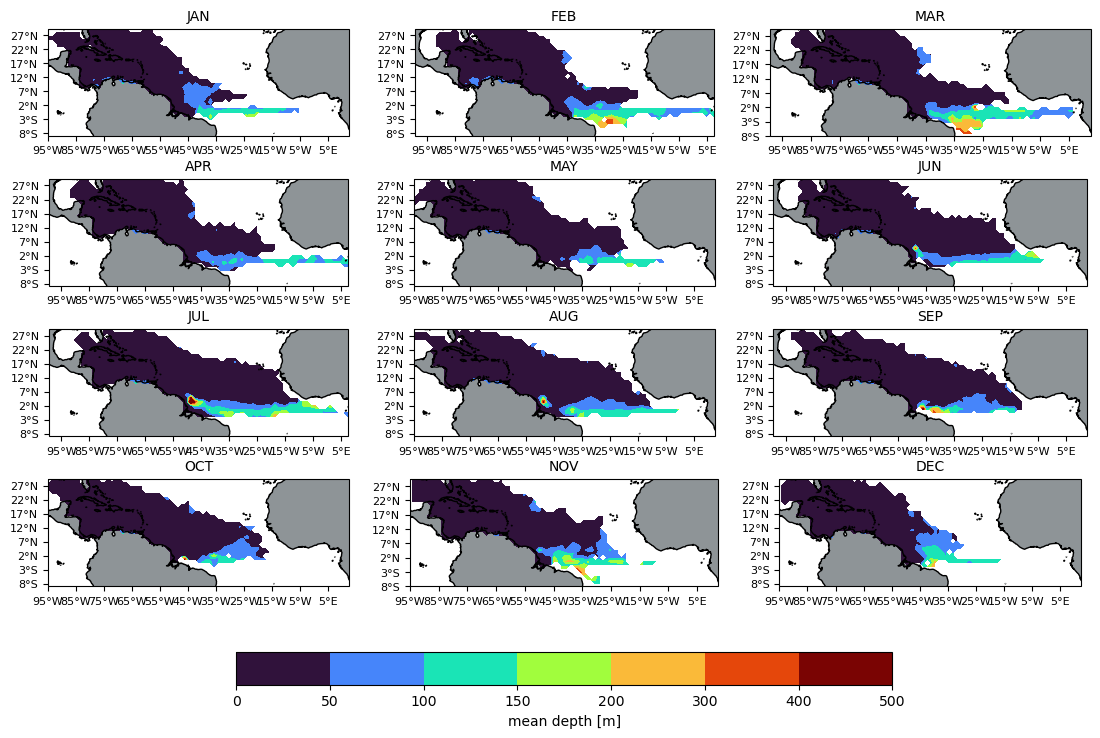

In [139]:
plot_monthly(mean_z.z, cmaps["z"], labels["z"], "z")

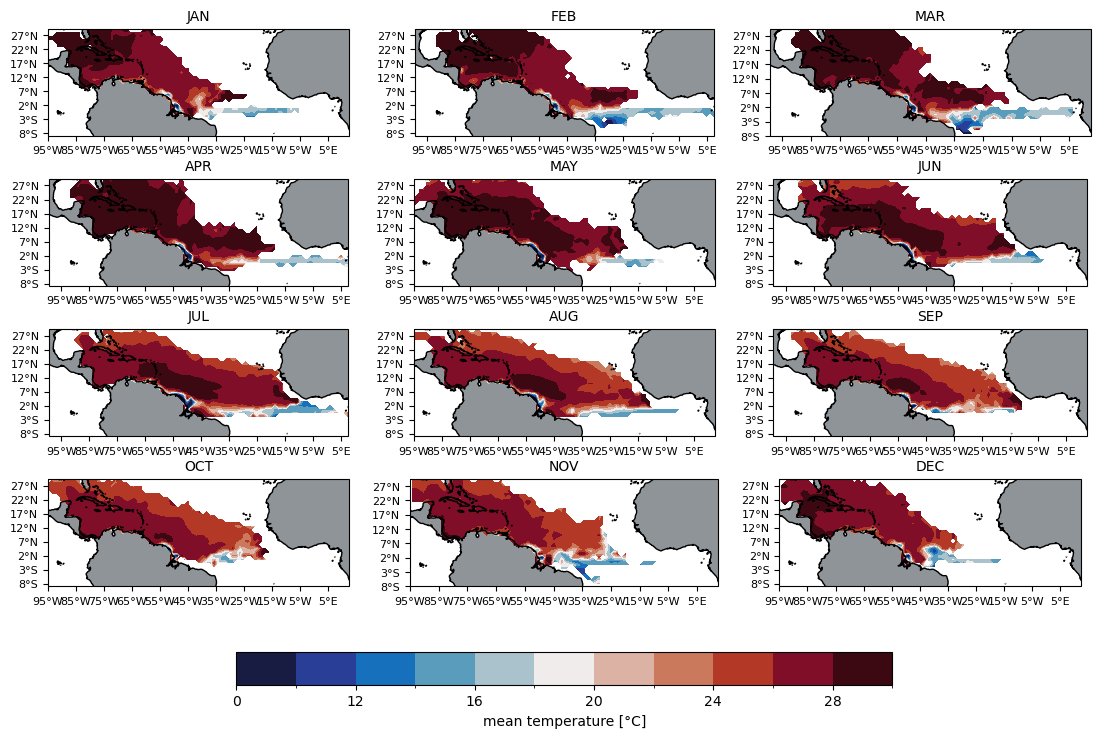

In [140]:
plot_monthly(mean_temp.temp, cmaps["temp"], labels["temp"], "temp")

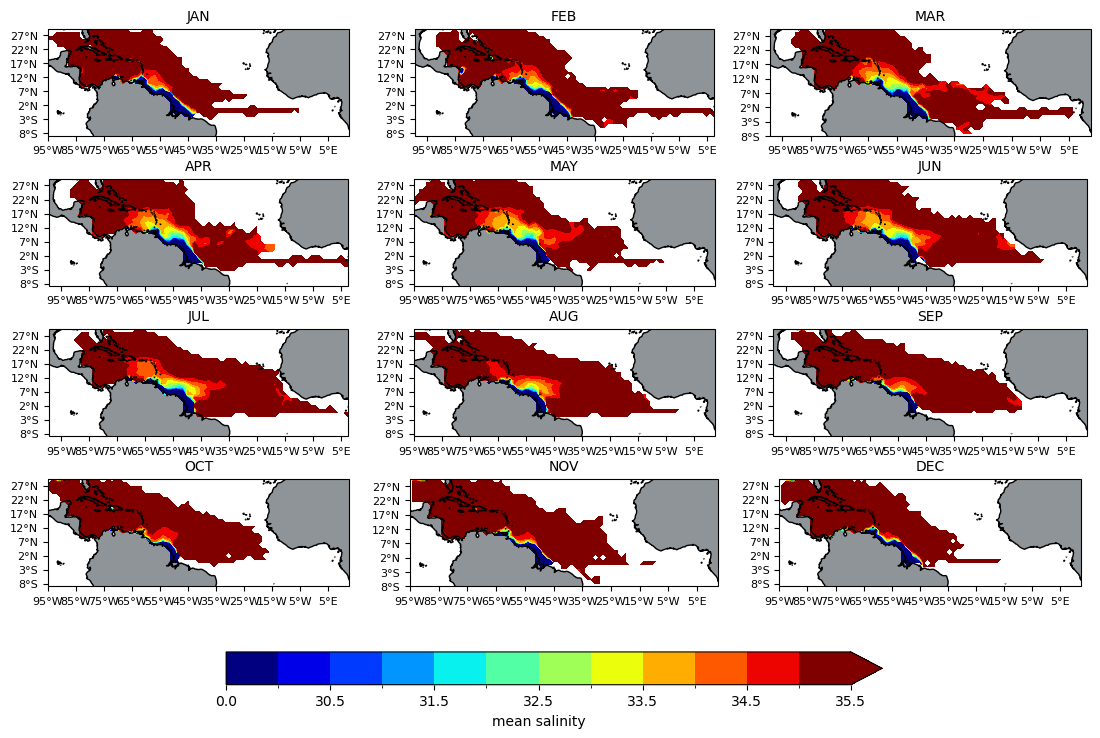

In [141]:
plot_monthly(mean_sal.sal, cmaps["sal"], labels["sal"], "sal")